In [51]:
## importation of libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split


In [52]:
# loading data 
data1=pd.read_csv('anime_dataset.csv')
data2=pd.read_csv('manga_dataset.csv')

df=data1.merge(data2,on="mal_id",how="inner")
df.head()


,mal_id,title_x,title_english_x,title_japanese_x,type_x,source,episodes,status_x,airing,aired_from,...,popularity_y,members_y,favorites_y,authors,serializations,genres_y,themes_y,demographics_y,synopsis_y,image_url_y
0,1,Cowboy Bebop,Cowboy Bebop,カウボーイビバップ,TV,Original,26.0,Finished Airing,False,1998-04-03,...,27,288956,23729,"Urasawa, Naoki",Big Comic Original,Award Winning|Drama|Mystery,Adult Cast|Psychological,Seinen,"Kenzou Tenma, a renowned Japanese neurosurgeon...",https://myanimelist.net/images/manga/3/258224.jpg
1,7,Witch Hunter Robin,Witch Hunter Robin,Witch Hunter ROBIN (ウイッチハンターロビン),TV,Original,26.0,Finished Airing,False,2002-07-03,...,160,102198,7654,"Morikawa, George",Shounen Magazine (Weekly),Award Winning|Sports,Combat Sports,Shounen,Makunouchi Ippo is a 16-year-old high school s...,https://myanimelist.net/images/manga/2/250313.jpg
2,8,Bouken Ou Beet,Beet the Vandel Buster,冒険王ビィト,TV,Manga,52.0,Finished Airing,False,2004-09-30,...,502,41150,1951,"Tanemura, Arina",Ribon Magazine,Comedy|Drama|Fantasy|Romance|Supernatural,Music|Showbiz,Shoujo,"At the tender age of 12, Mitsuki Kouyama has a...",https://myanimelist.net/images/manga/3/175970.jpg
3,15,Eyeshield 21,NaN,アイシールド21,TV,Manga,145.0,Finished Airing,False,2005-04-06,...,229,77872,5041,"Akamatsu, Ken",Shounen Magazine (Weekly),Action|Adventure|Comedy|Fantasy|Romance|Supern...,Harem|Martial Arts|School,Shounen,"Negi Springfield, a 10-year-old wizard who rec...",https://myanimelist.net/images/manga/1/259286.jpg
4,16,Hachimitsu to Clover,Honey and Clover,ハチミツとクローバー,TV,Manga,24.0,Finished Airing,False,2005-04-15,...,258,71264,3921,"Akamatsu, Ken",Shounen Magazine (Weekly),Award Winning|Comedy|Romance|Ecchi,Harem,Shounen,It is said that if a couple gets into the Univ...,https://myanimelist.net/images/manga/1/259287.jpg


In [53]:
# data info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11686 entries, 0 to 11685
Data columns (total 52 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   mal_id            11686 non-null  int64  
 1   title_x           11686 non-null  object 
 2   title_english_x   5633 non-null   object 
 3   title_japanese_x  11642 non-null  object 
 4   type_x            11665 non-null  object 
 5   source            11686 non-null  object 
 6   episodes          11408 non-null  float64
 7   status_x          11686 non-null  object 
 8   airing            11686 non-null  bool   
 9   aired_from        11460 non-null  object 
 10  aired_to          5254 non-null   object 
 11  duration          11686 non-null  object 
 12  rating            11470 non-null  object 
 13  score_x           8826 non-null   float64
 14  scored_by_x       8826 non-null   float64
 15  rank_x            9186 non-null   float64
 16  popularity_x      11686 non-null  int64 

In [54]:
# data description
df.describe()

,mal_id,episodes,score_x,scored_by_x,rank_x,popularity_x,members_x,favorites_x,year,chapters,volumes,score_y,scored_by_y,rank_y,popularity_y,members_y,favorites_y
count,11686.000000,11408.000000,8826.000000,8.826000e+03,9186.000000,11686.000000,1.168600e+04,11686.000000,3079.000000,9619.000000,10078.000000,6836.000000,6836.000000,7878.000000,11686.000000,11686.000000,11686.000000
mean,25853.577700,14.199684,6.503524,3.082467e+04,9772.338885,12852.300958,4.587920e+04,579.119117,2005.712244,24.805697,3.976384,6.963066,2490.857226,16547.943387,29244.332449,3599.738747,121.534400
std,21742.925566,52.442698,0.874144,1.256338e+05,6178.181191,8177.397995,1.850730e+05,5963.247571,13.761038,54.610230,6.341967,0.550303,9516.372316,9641.811553,19999.285216,15956.511917,1226.212033
min,1.000000,1.000000,1.890000,1.030000e+02,2.000000,1.000000,0.000000e+00,0.000000,1961.000000,1.000000,1.000000,4.600000,101.000000,2.000000,12.000000,24.000000,0.000000
25%,4000.750000,1.000000,5.910000,5.252500e+02,4548.250000,6103.500000,4.620000e+02,0.000000,1999.000000,5.000000,1.000000,6.610000,251.750000,7748.250000,12101.000000,166.000000,0.000000
50%,21691.000000,2.000000,6.530000,2.115000e+03,9013.000000,11625.000000,2.732500e+03,3.000000,2007.000000,9.000000,1.000000,6.920000,541.000000,17274.500000,26276.000000,535.000000,1.000000
75%,45819.500000,13.000000,7.140000,1.165375e+04,14477.500000,18985.750000,1.536475e+04,32.000000,2015.000000,21.000000,4.000000,7.280000,1451.000000,25620.000000,44475.750000,1751.000000,7.000000
max,64001.000000,3000.000000,9.150000,3.060289e+06,22548.000000,29935.000000,4.348557e+06,251194.000000,2027.000000,1957.000000,200.000000,9.340000,244081.000000,30168.000000,78630.000000,457036.000000,51533.000000


In [55]:
#duplicated columns
df.duplicated().sum()

np.int64(47)

In [56]:
#drop duplicates columns
df.drop_duplicates(inplace=True)


In [57]:
## looking for null rows
df.isnull().sum()*100/len(df)

mal_id               0.000000
title_x              0.000000
title_english_x     51.825758
title_japanese_x     0.378039
type_x               0.154652
source               0.000000
episodes             2.122175
status_x             0.000000
airing               0.000000
aired_from           1.855830
aired_to            54.901624
duration             0.000000
rating               1.692585
score_x             24.246069
scored_by_x         24.246069
rank_x              21.170204
popularity_x         0.000000
members_x            0.000000
favorites_x          0.000000
season              73.648939
year                73.648939
studios             29.383968
producers           45.115560
licensors           73.700490
genres_x            14.889595
themes_x            39.926110
demographics_x      64.077670
synopsis_x          11.134977
image_url_x          0.000000
title_y              0.000000
title_english_y     70.848011
title_japanese_y     3.797577
type_y               0.000000
chapters  

In [58]:
# droping null values  > 40%
cols_to_drop = [
    'title_english_x', 'title_english_y', 'title_japanese_x', 'title_japanese_y',
    'season', 'year', 'licensors', 'demographics_x', 'demographics_y', 
    'themes_y', 'aired_to', 'published_to', 'producers', 'serializations'
]
df = df.drop(columns=cols_to_drop)


In [59]:
## filling null values
df['score_x'] = df['score_x'].fillna(df['score_x'].mean())
df['scored_by_x'] = df['scored_by_x'].fillna(df['scored_by_x'].mean())
df['members_x'] = df['members_x'].fillna(df['members_x'].mean())
df['favorites_x'] = df['favorites_x'].fillna(df['favorites_x'].mean())
df['rank_x'] = df['rank_x'].fillna(df['rank_x'].mean())
df['popularity_x'] = df['popularity_x'].fillna(df['popularity_x'].mean())
df['episodes'] = df['episodes'].fillna(df['episodes'].mean())
df['rating'] = df['rating'].fillna(df['rating'].mode()[0])
df['genres_x'] = df['genres_x'].fillna(df['genres_x'].mode()[0])
df['studios'] = df['studios'].fillna(df['studios'].mode()[0])
df['source'] = df['source'].fillna(df['source'].mode()[0])
df['type_x'] = df['type_x'].    fillna(df['type_x'].mode()[0])
df['status_x'] = df['status_x'].fillna(df['status_x'].mode()[0])
df['aired_from'] = df['aired_from'].fillna(df['aired_from'].mode()[0])
df['published_from'] = df['published_from'].fillna(df['published_from'].mode()[0])
# Fill missing text columns
text_cols = [
    'genres_x',
    'themes_x',
    'synopsis_x',
    'studios',
    'authors'
]

for col in text_cols:
    df[col] = df[col].fillna('Unknown')

# Fill missing scores
df['score_x'] = df['score_x'].fillna(df['score_x'].mean())

In [60]:
df.columns

Index(['mal_id', 'title_x', 'type_x', 'source', 'episodes', 'status_x',
       'airing', 'aired_from', 'duration', 'rating', 'score_x', 'scored_by_x',
       'rank_x', 'popularity_x', 'members_x', 'favorites_x', 'studios',
       'genres_x', 'themes_x', 'synopsis_x', 'image_url_x', 'title_y',
       'type_y', 'chapters', 'volumes', 'status_y', 'publishing',
       'published_from', 'score_y', 'scored_by_y', 'rank_y', 'popularity_y',
       'members_y', 'favorites_y', 'authors', 'genres_y', 'synopsis_y',
       'image_url_y'],
      dtype='object')

# visualization

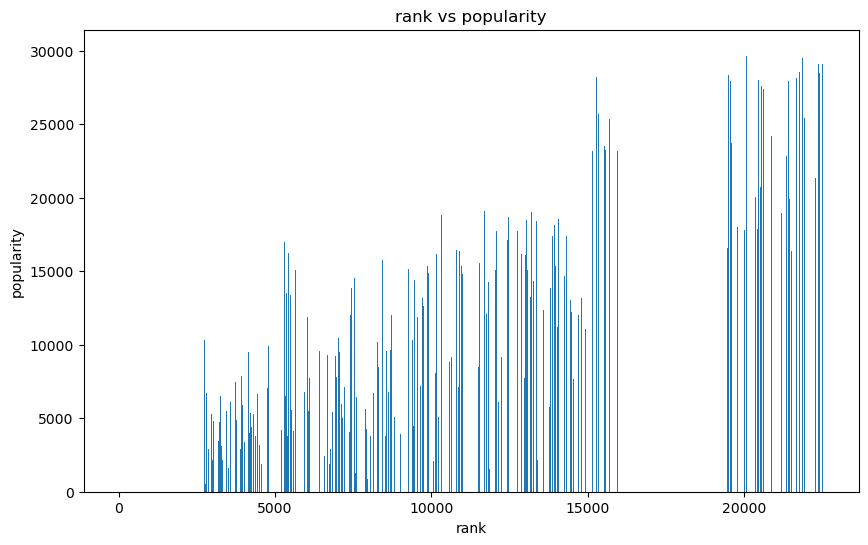

In [61]:
plt.figure(figsize=(10,6))
plt.bar(df["rank_x"],df["popularity_x"])
plt.xlabel("rank")
plt.ylabel("popularity")
plt.title("rank vs popularity")
plt.show()

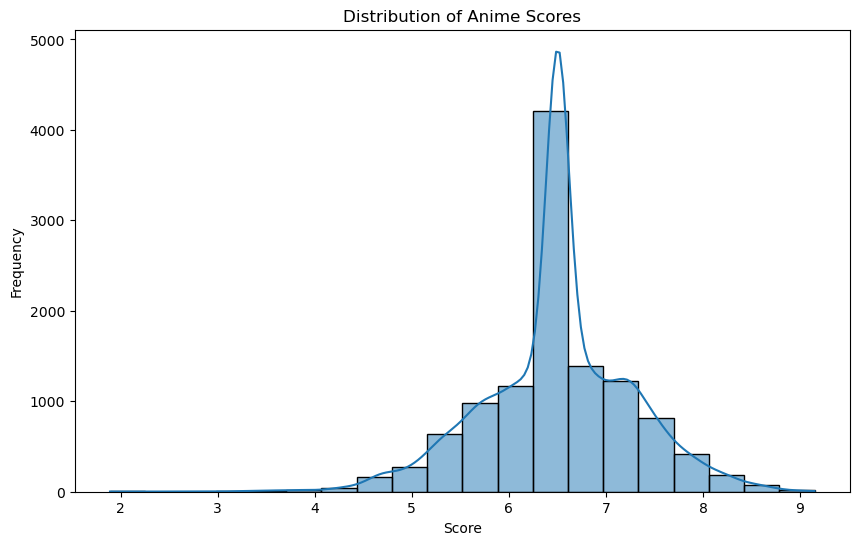

In [62]:
plt.figure(figsize=(10,6))
sns.histplot(df['score_x'], bins=20, kde=True)
plt.title('Distribution of Anime Scores')
plt.xlabel('Score')
plt.ylabel('Frequency')
plt.show()

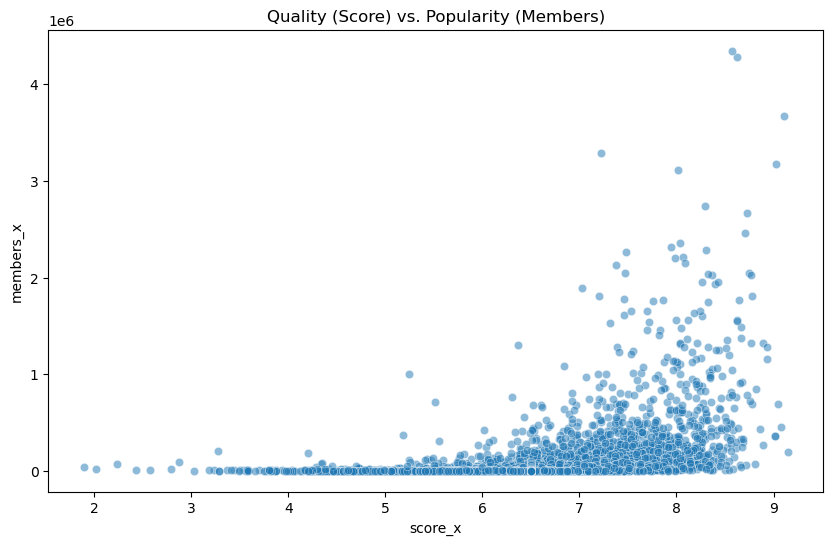

In [63]:
 # Anime Score vs. Members (Popularity)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='score_x', y='members_x', alpha=0.5)
plt.title('Quality (Score) vs. Popularity (Members)')
plt.show()

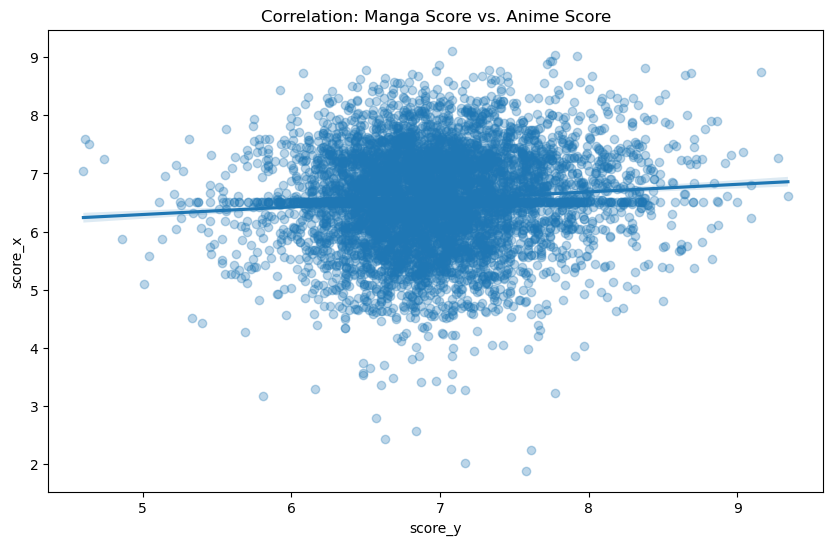

In [64]:
#  Anime vs. Manga Scores
plt.figure(figsize=(10, 6))
sns.regplot(data=df, x='score_y', y='score_x', scatter_kws={'alpha':0.3})
plt.title('Correlation: Manga Score vs. Anime Score')
plt.show()


In [65]:
# save cleaned data
df.to_csv('tableau.csv', index=False)

# MODELING